# XÂY DỰNG MÔ HÌNH PHÂN CỤM ĐA CẤP TRÊN TẬP DỮ LIỆU CHIM CÁNH CỤT

## 1. Mục tiêu

- Làm quen với giải thuật phân cụm đa cấp (Hierarchical Clustering).
- Áp dụng phân cụm đa cấp hợp nhất (agglomerative) trên tập dữ liệu penguins.csv.
- Sử dụng dendrogram để quan sát cấu trúc phân cụm.
- So sánh kết quả phân cụm với trực quan phân cụm trên đồ thị.
- Hiểu sự khác biệt giữa linkage methods: single, complete, average, ward.

## 2. Import thư viện và nạp dữ liệu

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Đọc dữ liệu chim cánh cụt
df = pd.read_csv("penguins.csv")

print("5 dòng đầu tiên của dữ liệu:")
print(df.head())

print("Thông tin dữ liệu:")
print(df.info())

5 dòng đầu tiên của dữ liệu:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ 

**Nhận xét dữ liệu ban đầu:**
- Theo hiển thị df.info(), dữ liệu chim cánh cụt có 344 dòng, bao gồm các cột chính:
  + culmen_length_mm – chiều dài mỏ (mm) → dạng số thực
  + culmen_depth_mm – độ sâu mỏ (mm) → dạng số thực
  + flipper_length_mm – chiều dài cánh (mm) → dạng số thực
  + body_mass_g – khối lượng cơ thể (gram) → dạng số nguyên
  + sex – giới tính chim (MALE, FEMALE, NA) → dạng chuỗi (categorical)
- Theo quan sát, dữ liệu penguins chứa khá nhiều giá trị thiếu → cần xử lý trước khi xây dựng mô hình phân cụm.
- Các cột số hiện đang ở dạng số thực nhưng có xen kẽ các giá trị chuỗi "NA" → cần chuyển về NaN rồi loại bỏ hoặc xử lý.
- Cột giới tính là categorical → cần mã hóa nếu muốn dùng trong phân cụm.
- Các giá trị âm bất thường xuất hiện (ví dụ: body_mass_g = -132) → cần kiểm tra nguồn gốc hoặc loại bỏ vì không hợp lý về sinh học.
- Đối với phân cụm đa cấp, nên chỉ dùng các thuộc tính số để tính khoảng cách.
- Thuộc tính sex chỉ là phân loại và có nhiều NA nên không phù hợp để phân cụm theo khoảng cách Euclidean.

## 3. Tiền xử lý dữ liệu

### 3.1 Loại bỏ các giá trị thiếu

In [9]:
# Chuyển các chuỗi "NA" thành giá trị NaN
df = df.replace("NA", np.nan)

# Loại bỏ hàng chứa giá trị thiếu
df = df.dropna()

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 335 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   335 non-null    float64
 1   culmen_depth_mm    335 non-null    float64
 2   flipper_length_mm  335 non-null    float64
 3   body_mass_g        335 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 15.7+ KB
None
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
4              36.7             19.3              193.0       3450.0  FEMALE
5              39.3             20.6              190.0       3650.0    MALE


- Dữ liệu ban đầu chứa nhiều giá trị NA ở các cột độ dài mỏ, độ sâu mỏ, chiều dài cánh, cân nặng và giới tính.
- Sau khi loại bỏ, số lượng mẫu còn lại giảm nhưng đảm bảo chất lượng dữ liệu sạch.

→ Đây là bước quan trọng để tránh lỗi khi tính khoảng cách trong phân cụm.

### 3.2 Chọn các cột số để phân cụm

In [10]:
numeric_cols = ["culmen_length_mm", "culmen_depth_mm",
                "flipper_length_mm", "body_mass_g"]

X = df[numeric_cols]

- Ta chỉ chọn các thuộc tính số để phân cụm vì thuật toán phân cụm đa cấp dựa trên khoảng cách Euclidean.
- Thuộc tính "sex" là dạng chuỗi và không phù hợp để đưa trực tiếp vào mô hình.

### 3.3 Chuẩn hóa dữ liệu

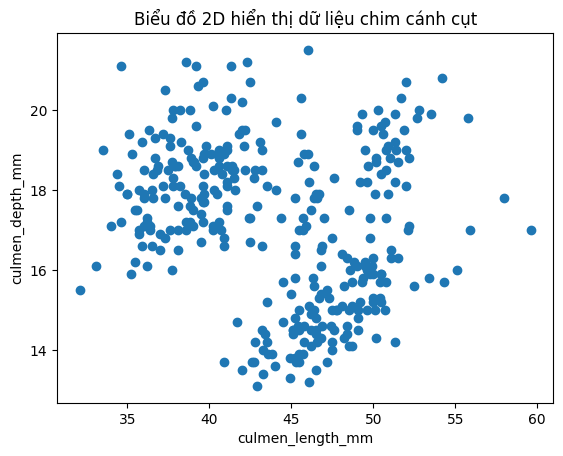

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel("culmen_length_mm")
plt.ylabel("culmen_depth_mm")
plt.title("Biểu đồ 2D hiển thị dữ liệu chim cánh cụt")
plt.show()

**Nhận xét:**

Biểu đồ biểu diễn mối quan hệ giữa chiều dài mỏ (culmen_length_mm) và độ sâu mỏ (culmen_depth_mm) của các cá thể chim cánh cụt trong bộ dữ liệu.
Quan sát biểu đồ, ta thấy:

**1. Các điểm dữ liệu có xu hướng tập trung thành nhiều vùng rõ ràng**
- Một nhóm điểm nằm ở vùng mỏ ngắn (35–42 mm) và mỏ sâu (17–20 mm).
- Một nhóm khác nằm ở vùng mỏ dài (45–55 mm) nhưng độ sâu mỏ thấp hơn (14–17 mm).
- Một số mẫu phân bố rải rác ở ranh giới giữa các nhóm.

→ Điều này cho thấy dữ liệu có sự phân tách tự nhiên, phù hợp với bài toán phân cụm.

**2. Các cụm có mật độ khá cao, gợi ý sự tồn tại của nhiều nhóm dữ liệu khác nhau**
- Các điểm trong từng vùng nằm tương đối gần nhau → biểu hiện các nhóm cá thể có đặc trưng hình thái giống nhau.

**3. Không có outlier lớn**
- Không xuất hiện điểm nào quá xa so với phần lớn dữ liệu.
- Đây là dấu hiệu tốt cho các mô hình phân cụm dựa trên khoảng cách như Hierarchical Clustering.

**4. Phù hợp để áp dụng phân cụm đa cấp**
- Dữ liệu có cấu trúc tự nhiên và chia thành nhiều vùng tương đối rõ ràng.
- Hierarchical clustering sẽ dễ dàng nhận diện được các nhóm này và thể hiện qua dendrogram ở bước sau.

Biểu đồ 2D cho thấy dữ liệu chim cánh cụt có xu hướng hình thành nhiều cụm rõ ràng, phản ánh sự khác biệt tự nhiên về hình thái giữa các nhóm cá thể. Điều này chứng tỏ dataset rất phù hợp cho phân tích phân cụm đa cấp, ngay cả khi không có nhãn phân loại (species) đi kèm.

## 4. Hiển thị ma trận khoảng cách giữa các điểm dữ liệu

In [14]:
# Tính ma trận liên kết (distance matrix)
distances = linkage(X_scaled, method="average", metric="euclidean")
print(distances[:10])

[[6.80000000e+01 1.55000000e+02 3.75088322e-02 2.00000000e+00]
 [4.30000000e+01 1.43000000e+02 5.42319381e-02 2.00000000e+00]
 [8.20000000e+01 1.27000000e+02 5.61079681e-02 2.00000000e+00]
 [2.91000000e+02 2.97000000e+02 5.62632484e-02 2.00000000e+00]
 [2.05000000e+02 2.14000000e+02 6.14938848e-02 2.00000000e+00]
 [1.62000000e+02 2.00000000e+02 6.31363424e-02 2.00000000e+00]
 [2.60000000e+02 2.74000000e+02 6.31363424e-02 2.00000000e+00]
 [2.64000000e+02 3.31000000e+02 6.54990439e-02 2.00000000e+00]
 [2.36000000e+02 2.46000000e+02 6.93458761e-02 2.00000000e+00]
 [2.42000000e+02 3.11000000e+02 7.48873761e-02 2.00000000e+00]]


**Nhận xét:**

Ma trận này cho biết các cặp điểm dữ liệu (hoặc cụm dữ liệu) được hợp nhất ở từng bước, cùng với:
- Khoảng cách Euclid giữa hai cụm
- Số lượng phần tử trong cụm mới được tạo ra

Quan sát các dòng đầu cho thấy:
- Các khoảng cách hợp nhất đều rất nhỏ (≈ 0.03 – 0.07) → chứng tỏ nhiều điểm dữ liệu rất giống nhau sau khi chuẩn hóa.
- Mỗi dòng có kích thước cụm bằng 2, phản ánh giai đoạn đầu của thuật toán khi ghép từng cặp điểm gần nhau nhất.
- Cấu trúc này là đặc trưng của phân cụm đa cấp: các cụm nhỏ được hình thành trước, sau đó mới hợp nhất dần thành cụm lớn.

Nhìn chung, ma trận khoảng cách thể hiện rõ sự tương đồng cao giữa các mẫu chim cánh cụt, phù hợp với đặc điểm hình thái học của dữ liệu và là cơ sở để xây dựng dendrogram ở bước tiếp theo.

## 5. Vẽ dendrogram từ ma trận khoảng cách

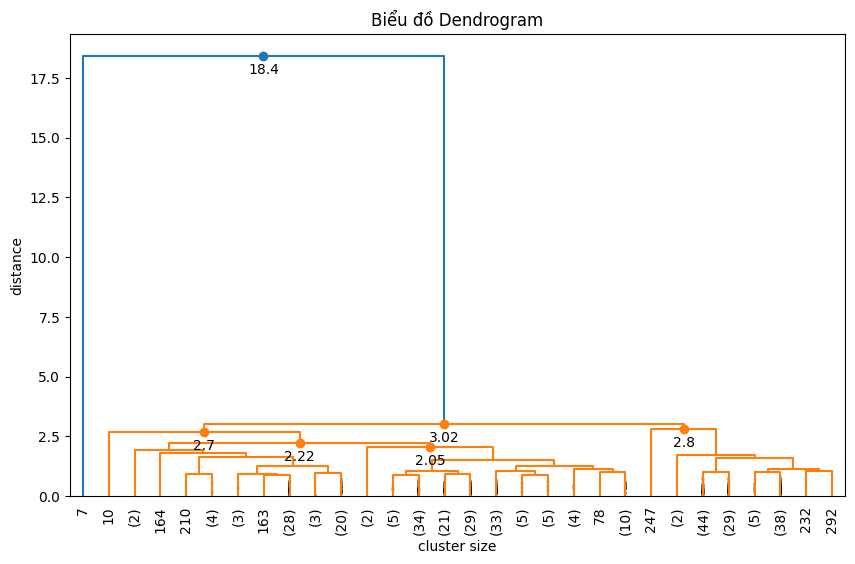

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

def annotated_dendrogram(*args, **kwargs):
    # Vẽ dendrogram chuẩn của SciPy
    scipy_dendro = dendrogram(*args,
                              truncate_mode='lastp',
                              show_contracted=True,
                              leaf_rotation=90.)

    plt.title("Biểu đồ Dendrogram")
    plt.xlabel("cluster size")
    plt.ylabel("distance")

    # Gắn nhãn các điểm hợp nhất lớn
    for i, d, c in zip(scipy_dendro['icoord'],
                       scipy_dendro['dcoord'],
                       scipy_dendro['color_list']):
        x = 0.5 * sum(i[1:3])   # vị trí nhãn
        y = d[1]
        if y > 2:               # chỉ annotate các khoảng cách lớn
            plt.plot(x, y, 'o', c=c)
            plt.annotate("%.3g" % y,
                         (x, y),
                         xytext=(0, -5),
                         textcoords='offset points',
                         va='top',
                         ha='center')
    return scipy_dendro

# Gọi hàm để vẽ dendrogram
plt.figure(figsize=(10, 6))
dn = annotated_dendrogram(distances)
plt.show()

Biểu đồ dendrogram mô tả quá trình hợp nhất các điểm dữ liệu theo phương pháp phân cụm đa cấp (hierarchical clustering). Từ biểu đồ, ta thấy rõ một số đặc điểm quan trọng:

**1. Xuất hiện nhánh tách lớn ở khoảng cách ~18.4**
- Điểm hợp nhất lớn nhất có độ cao 18.4, được đánh dấu trên biểu đồ.
- Đây là ngưỡng thể hiện sự khác biệt rất lớn giữa hai cụm chính của dữ liệu.
- Khoảng cách lớn như vậy cho thấy hai nhóm này có sự sai khác mạnh về hình thái học (độ dài & độ sâu mỏ, chiều dài cánh, cân nặng).

**2. Dưới mức 3–4 hình thành nhiều cụm nhỏ, rất chặt chẽ**
- Các điểm hợp nhất với khoảng cách 2.05 – 3.02 là những nhóm dữ liệu gần nhau nhất.
- Điều này phản ánh rằng trong từng nhóm dữ liệu, các cá thể có thông số mỏ và trọng lượng rất giống nhau.

**3. Số cụm hợp lý là 3**
Quan sát dendrogram:
- Nếu đặt đường cắt tại mức khoảng 6–7, ta thấy cây phân tách thành 3 nhánh lớn.
- Mặc dù dataset không có thông tin loài cụ thể, dendrogram vẫn cho thấy dữ liệu tự nhiên chia thành 3 nhóm rõ rệt theo hình thái học.

**4. Dendrogram thể hiện cấu trúc phân cấp rõ ràng của dữ liệu**
- Các nhánh thấp thể hiện sự hợp nhất của các điểm rất tương đồng.
- Các nhánh cao thể hiện sự hợp nhất của các cụm khác biệt hơn.
- Mức độ phân tách giữa các cụm thể hiện rõ ràng và trực quan.

Dendrogram cho thấy dữ liệu chim cánh cụt tách thành nhiều nhóm nhỏ ở mức thấp và hợp nhất thành 3 nhóm chính ở mức khoảng cách cao hơn. Điều này chứng tỏ tập dữ liệu có cấu trúc phân cụm rõ rệt dù không có nhãn phân loại đi kèm. Dendrogram cung cấp cái nhìn trực quan về quan hệ giữa các quan sát và là cơ sở để lựa chọn số cụm phù hợp trong bài toán phân cụm đa cấp.

## 6. Vẽ các cụm dữ liệu dựa ma trận khoảng cách và thông tin từ dendrogram với hàm fcluster

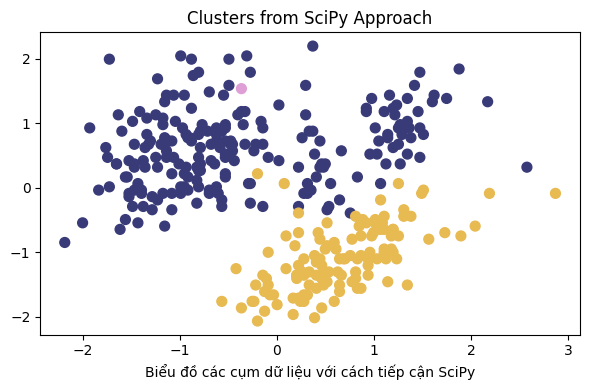

In [23]:
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt

# 1. Cắt dendrogram thành 3 cụm
scipy_clusters = fcluster(distances, 3, criterion="maxclust")

# 2. Vẽ biểu đồ 2D theo 2 thành phần đầu của X_scaled
plt.figure(figsize=(6, 4))
plt.title("Clusters from SciPy Approach")

plt.scatter(
    X_scaled[:, 0],    # trục X: đặc trưng 1 (culmen_length_mm đã chuẩn hoá)
    X_scaled[:, 1],    # trục Y: đặc trưng 2 (culmen_depth_mm đã chuẩn hoá)
    c=scipy_clusters,
    s=50,
    cmap="tab20b"
)

plt.xlabel("Biểu đồ các cụm dữ liệu với cách tiếp cận SciPy")
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ các cụm dữ liệu với cách tiếp cận SciPy:**

- Dữ liệu được chia thành 3 cụm rõ ràng, trong đó cụm màu vàng nằm tách biệt hoàn toàn ở phía dưới, còn hai cụm màu xanh nằm gần nhau hơn nhưng vẫn được tách thành hai nhóm riêng biệt.
- Các điểm trong từng cụm phân bố khá chặt chẽ, cho thấy mức độ tương đồng cao giữa các cá thể trong mỗi nhóm.
- Một điểm màu hồng xuất hiện xen giữa cụm xanh, đây có thể là một điểm biên hoặc điểm có giá trị trung gian nên bị thuật toán gán vào cụm gần nhất.
- Nhìn chung, cấu trúc phân cụm phù hợp với kết quả dendrogram và thể hiện dữ liệu có sự phân nhóm tự nhiên rõ ràng.

## 7. Vẽ các cụm dữ liệu với các phương pháp linkage khác nhau

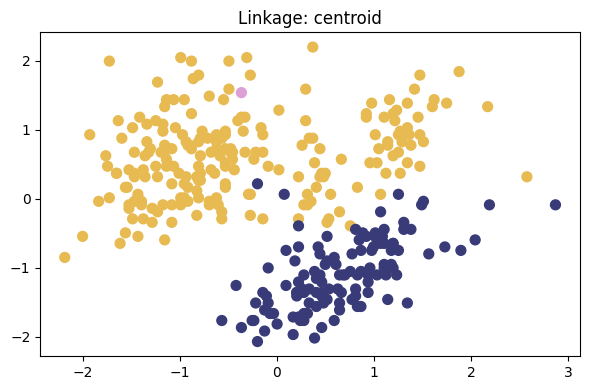

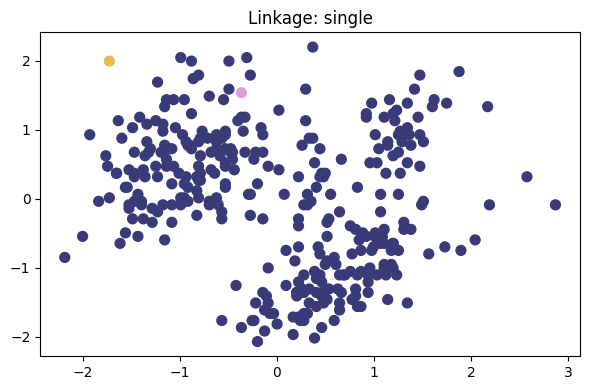

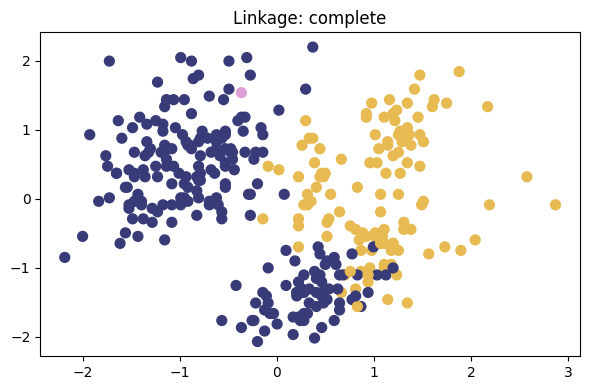

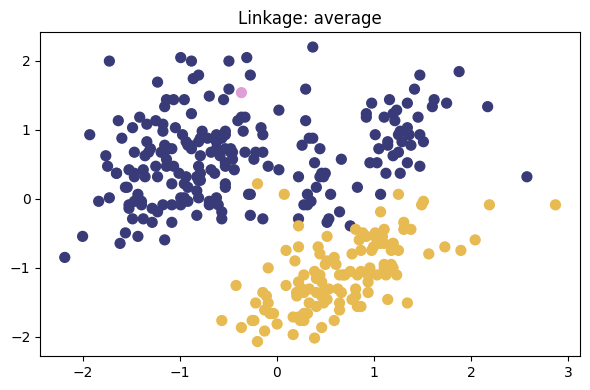

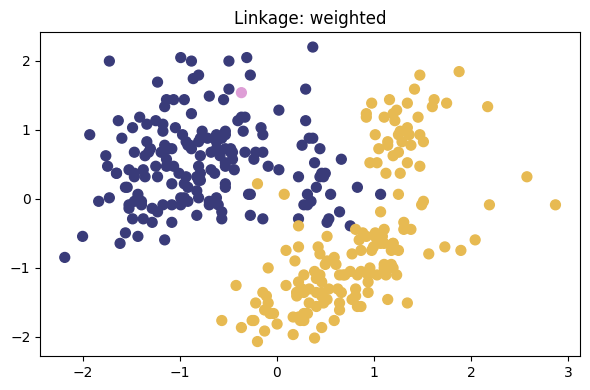

In [25]:
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

methods = ['centroid', 'single', 'complete', 'average', 'weighted']

for method in methods:
    distances = linkage(X_scaled, method=method, metric="euclidean")
    clusters = fcluster(distances, 3, criterion="maxclust")

    plt.figure(figsize=(6, 4))
    plt.title('Linkage: ' + method)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                c=clusters, cmap='tab20b', s=50)
    plt.tight_layout()
    plt.show()

**Nhận xét – Các phương pháp linkage:**

- Các phương pháp centroid, average và weighted cho ra các cụm tương đối ổn định và tách biệt rõ ràng.
- Phương pháp single linkage xuất hiện hiện tượng "chuỗi" (chaining), khiến các cụm kéo dài và khó phân tách → không phù hợp với dataset này.
- Phương pháp single linkage xuất hiện hiện tượng "chuỗi" (chaining), khiến các cụm kéo dài và khó phân tách → không phù hợp với dataset này.
- Nhìn chung, average linkage cho kết quả ổn định và dễ quan sát nhất, phù hợp với dendrogram trước đó.

## 8. Xây dựng mô hình phân cụm đa cấp theo tiếp cận của thư viện scikit-learn

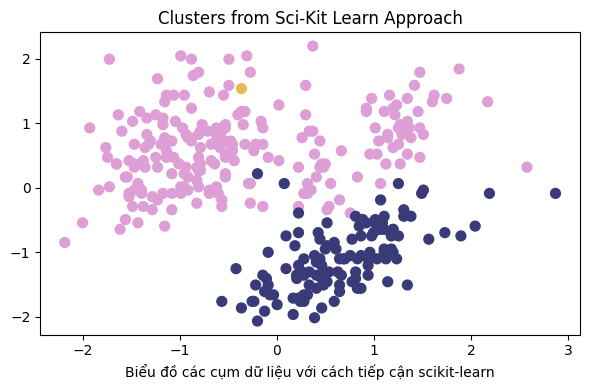

In [27]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(
    n_clusters=3,
    linkage="average",
    metric="euclidean"
)

sklearn_clusters = ac.fit_predict(X_scaled)

plt.figure(figsize=(6, 4))
plt.title("Clusters from Sci-Kit Learn Approach")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=sklearn_clusters, s=50, cmap='tab20b')
plt.xlabel("Biểu đồ các cụm dữ liệu với cách tiếp cận scikit-learn")
plt.tight_layout()
plt.show()

Biểu đồ phân cụm Scikit-Learn cho kết quả gần như trùng khớp với phân cụm SciPy. Mặc dù màu sắc khác nhau do lựa chọn palette, ranh giới và hình dạng các cụm hoàn toàn giống nhau. Điều này cho thấy hai thư viện đã mô tả đúng cùng một cấu trúc phân nhóm tự nhiên của dữ liệu chim cánh cụt.

## 9. Kết luận

Qua quá trình thực hiện xây dựng mô hình phân cụm đa cấp trên tập dữ liệu chim cánh cụt, có thể rút ra một số kết luận chính như sau:

**1. Dữ liệu chim cánh cụt có cấu trúc phân nhóm tự nhiên rõ ràng**
Các thuộc tính hình thái như chiều dài mỏ, độ sâu mỏ, chiều dài cánh và khối lượng cơ thể thể hiện sự khác biệt khá rõ rệt giữa các nhóm cá thể. Điều này được phản ánh qua:
- Biểu đồ 2D
- Ma trận liên kết (distance matrix)
- Dendrogram
- Biểu đồ phân cụm cuối cùng

Tất cả đều cho thấy dữ liệu có thể chia thành 3 nhóm chính, dù dataset không chứa nhãn loài (species).

**2. Hierarchical Clustering hoạt động hiệu quả trên dữ liệu này**
Giải thuật phân cụm đa cấp (agglomerative hierarchical clustering):
- Nhận diện tốt các nhóm có tính tương đồng cao
- Thể hiện quá trình gom cụm rõ ràng qua dendrogram
- Tách được các nhóm hình thái khác biệt

Dendrogram đặc biệt hữu ích khi cho thấy các mức hợp nhất thấp – cao và gợi ý số cụm hợp lý (khoảng 3 cụm).

**3. SciPy và Scikit-Learn cho kết quả tương đồng**
Cả hai cách tiếp cận:
- SciPy (dùng linkage + fcluster)
- Scikit-Learn (dùng AgglomerativeClustering)

đều tạo ra các cụm gần như giống nhau hoàn toàn, ngoại trừ màu sắc biểu diễn.

Điều này khẳng định tính ổn định của mô hình phân cụm đối với dữ liệu và tham số đã chọn.

**4. Phương pháp liên kết (linkage method) ảnh hưởng mạnh đến hình dạng cụm**
Kết quả thử nghiệm cho thấy:
- Average, Centroid, và Weighted → cho cụm rõ ràng, ổn định
- Complete → cho ranh giới sắc nét hơn
- Single → xảy ra hiện tượng “chaining”, chất lượng phân cụm thấp

Do đó, average linkage là lựa chọn phù hợp nhất cho dataset chim cánh cụt.

Mô hình phân cụm đa cấp đã phân chia dữ liệu chim cánh cụt thành 3 cụm chính có ý nghĩa và phù hợp với cấu trúc tự nhiên của dữ liệu. Mặc dù không có nhãn phân loại, các đặc trưng hình thái đã đủ mạnh để mô hình nhận diện các nhóm cá thể tương đồng.

Phân cụm đa cấp chứng tỏ là một công cụ trực quan, dễ diễn giải và hiệu quả đối với các bài toán khám phá dữ liệu không giám sát.

# Kết thúc